# Development of a CNN Model with the Mel-Spectogram as it's input feature:

## Imports:

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Geral:

In [4]:
BATCH_SIZE = 32
SAMPLE_RATE = 16000 # Taxa de amostragem comum para fala
AUDIO_DURATION_S = 1 # Duração de cada áudio em segundos (ajuste se necessário)
SAMPLES_PER_AUDIO = SAMPLE_RATE * AUDIO_DURATION_S

FRAME_LENGTH = 512  # Comprimento de cada frame em amostras
FRAME_STEP = 256    # Passo entre os frames em amostras (controls overlap)
N_FFT = 512

N_MELS = 128        # Número de "bins" (faixas de frequência) na escala Mel
F_MIN = 20          # Frequência mínima
F_MAX = SAMPLE_RATE / 2 # Frequência máxima (Nyquist)

AUTOTUNE = tf.data.AUTOTUNE

In [5]:
def get_label(file_path: tf.Tensor) -> tf.Tensor:
    """Extrai o rótulo (label) como um inteiro a partir do caminho do arquivo."""
    # Ex: 'dataset/train/Classe1/audio.wav' -> 'Classe1'
    parts = tf.strings.split(file_path, '/')
    label_str = parts[-2]
    # Converte o nome da classe em um índice inteiro
    label_int = tf.argmax(label_str == CLASS_NAMES)
    return tf.cast(label_int, tf.int64)

In [6]:
def decode_audio(file_path: tf.Tensor) -> tf.Tensor:
    """Lê, decodifica, normaliza e garante o comprimento fixo do áudio."""
    # Lê o arquivo binário
    audio_binary = tf.io.read_file(file_path)
    # Decodifica o .wav para um Tensor. desired_channels=1 para forçar mono.
    audio, sr = tf.audio.decode_wav(audio_binary, desired_channels=1)

    # Remove a dimensão do canal (de [samples, 1] para [samples])
    waveform = tf.squeeze(audio, axis=-1)

    # Garante que o áudio tenha exatamente SAMPLES_PER_AUDIO
    # Se for mais curto, preenche com zeros (padding). Se for mais longo, corta.
    waveform = tf.cast(waveform, tf.float32)
    current_len = tf.shape(waveform)[0]

    if current_len < SAMPLES_PER_AUDIO:
        padding = tf.zeros(SAMPLES_PER_AUDIO - current_len, dtype=tf.float32)
        waveform = tf.concat([waveform, padding], 0)
    
    waveform = waveform[:SAMPLES_PER_AUDIO]

    # Garante que a forma (shape) é conhecida pelo TensorFlow
    waveform.set_shape([SAMPLES_PER_AUDIO])

    return waveform

In [7]:
def get_mel_spectrogram(waveform: tf.Tensor) -> tf.Tensor:
    """Converte a forma de onda (waveform) de áudio em um Mel-Espectrograma."""
    # 1. Calcula o espectrograma usando STFT
    stft = tf.signal.stft(
        waveform,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=N_FFT
    )
    # Pega a magnitude (ignora a fase)
    spectrogram = tf.abs(stft)

    # 2. Converte para a escala Mel
    # AQUI ESTÁ A CORREÇÃO: trocamos os nomes dos argumentos
    mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MELS,
        num_spectrogram_bins=stft.shape[-1],
        sample_rate=SAMPLE_RATE,
    )
    mel_spectrogram = tf.tensordot(spectrogram, mel_filterbank, 1)
    
    # Define o shape para evitar problemas posteriores
    mel_spectrogram.set_shape(spectrogram.shape[:-1].concatenate(mel_filterbank.shape[-1:]))
    
    # 3. Converte para dB para melhor representação (opcional, mas recomendado)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    # 4. Adiciona uma dimensão de "canal" para compatibilidade com CNNs (ex: Conv2D)
    # O formato final será (tempo, frequência, canais=1)
    return tf.expand_dims(log_mel_spectrogram, axis=-1)


def process_path(file_path: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    """Função principal que combina todas as etapas de processamento."""
    label = get_label(file_path)
    waveform = decode_audio(file_path)
    mel_spectrogram = get_mel_spectrogram(waveform)
    return mel_spectrogram, label

# --- 4. Função para Criar o Dataset Final ---

def create_dataset(data_path: Path, shuffle: bool = True):
    """Cria um tf.data.Dataset otimizado a partir de um diretório."""
    # Lista todos os arquivos .wav de forma recursiva dentro do diretório
    ds = tf.data.Dataset.list_files(str(data_path / '*/*.wav'), shuffle=shuffle)

    # Mapeia a função de processamento para cada arquivo.
    # num_parallel_calls=AUTOTUNE permite que o TensorFlow processe múltiplos arquivos em paralelo.
    ds = ds.map(process_path, num_parallel_calls=AUTOTUNE)

    # Armazena em cache os espectrogramas após a primeira época.
    # Isso acelera muito o treinamento se o dataset couber na RAM ou em um arquivo de cache.
    ds = ds.cache()

    # Embaralha os dados (importante para o treino)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000) # O buffer_size deve ser razoavelmente grande

    # Agrupa os dados em lotes (batches)
    ds = ds.batch(BATCH_SIZE)

    # Pré-carrega o próximo lote enquanto o lote atual está sendo processado pela GPU/CPU.
    # Essencial para evitar gargalos.
    ds = ds.prefetch(buffer_size=AUTOTUNE)

    return ds

## No Data Augmentation:

In [8]:
DATA_DIR = Path('../dataset')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'validation'
TEST_DIR = DATA_DIR / 'test'

In [9]:
CLASS_NAMES = np.array(sorted([item.name for item in TRAIN_DIR.glob('*') if item.is_dir()]))
print(f"Classes encontradas: {CLASS_NAMES}")

Classes encontradas: ['_silence_' '_unknown_' 'go' 'no' 'off' 'on' 'stop']


In [10]:
print("\nCriando o dataset de treinamento...")
train_ds = create_dataset(TRAIN_DIR, shuffle=True)

print("Criando o dataset de validação...")
val_ds = create_dataset(VALID_DIR, shuffle=False)

print("Criando o dataset de teste...")
test_ds = create_dataset(TEST_DIR, shuffle=False)


Criando o dataset de treinamento...


I0000 00:00:1758775339.973830   38485 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9608 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


Criando o dataset de validação...
Criando o dataset de teste...


In [11]:
print("\n--- Verificação do Pipeline ---")
# Pega um lote do dataset de treino para inspecionar os shapes
for mel_specs, labels in train_ds.take(1):
    print(f"Shape do lote de Mel-espectrogramas: {mel_specs.shape}")
    print(f"Shape do lote de labels: {labels.shape}")
    print(f"Tipo de dado dos Mel-espectrogramas: {mel_specs.dtype}")
    print(f"Tipo de dado dos labels: {labels.dtype}")
    
    # Mostra um exemplo de Mel-espectrograma (o primeiro do lote)
    first_spectrogram = mel_specs[0]
    print(f"Shape de um único Mel-espectrograma: {first_spectrogram.shape}")
    
    first_label = labels[0]
    print(f"Label do primeiro item do lote: {first_label.numpy()} ({CLASS_NAMES[first_label]})")



--- Verificação do Pipeline ---
Shape do lote de Mel-espectrogramas: (32, 61, 128, 1)
Shape do lote de labels: (32,)
Tipo de dado dos Mel-espectrogramas: <dtype: 'float32'>
Tipo de dado dos labels: <dtype: 'int64'>
Shape de um único Mel-espectrograma: (61, 128, 1)
Label do primeiro item do lote: 4 (off)


2025-09-25 01:42:23.537040: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-25 01:42:23.538151: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Formato (shape) do lote de mel-espectrogramas: (32, 61, 128, 1)
Formato (shape) do lote de rótulos: (32,)


2025-09-25 01:42:26.000895: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


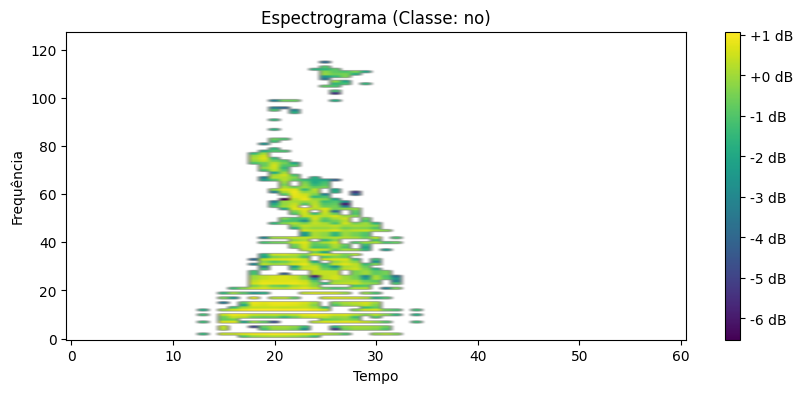

In [12]:
for mels, labels in train_ds.take(1):
    input_shape = mels.shape[1:]
    print(f"\nFormato (shape) do lote de mel-espectrogramas: {mels.shape}")
    print(f"Formato (shape) do lote de rótulos: {labels.shape}")
    
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.math.log(mels[0, :, :, 0] + 1e-6).numpy().T, aspect='auto', origin='lower')
    plt.title(f"Espectrograma (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Frequência")
    plt.xlabel("Tempo")
    plt.colorbar(format='%+2.0f dB')
    plt.show()
    break

### Training:

In [13]:
model_mel_espectograma = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(7, activation='softmax')
])

model_mel_espectograma.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 61, 128, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 61, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14336)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,670,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,818,055 (14.56 MB)

 Trainable params: 3,816,775 (14.56 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [14]:
model_mel_espectograma.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [16]:
history = model_mel_espectograma.fit(train_ds, validation_data=val_ds, callbacks = callbacks, epochs=100, batch_size=32, verbose=1)

Epoch 1/100


I0000 00:00:1758775384.540903   38670 service.cc:152] XLA service 0x7be6f4001ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758775384.540916   38670 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-09-25 01:43:04.578067: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758775384.775302   38670 cuda_dnn.cc:529] Loaded cuDNN version 91002


 22/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1942 - loss: 2.6651

I0000 00:00:1758775387.101710   38670 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


601/601 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.4572 - loss: 1.4809 - val_accuracy: 0.6583 - val_loss: 0.9498
Epoch 2/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6468 - loss: 0.9528 - val_accuracy: 0.7394 - val_loss: 0.7550
Epoch 3/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7010 - loss: 0.8171 - val_accuracy: 0.7512 - val_loss: 0.6626
Epoch 4/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7358 - loss: 0.7256 - val_accuracy: 0.6863 - val_loss: 0.8750
Epoch 5/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7284 - loss: 0.7396 - val_accuracy: 0.6541 - val_loss: 0.8917
Epoch 6/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7515 - loss: 0.6834 - val_accuracy: 0.7829 - val_loss: 0.6221
Epoch 7/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7612 - loss: 0.6504 - val_accuracy: 0.7198 - val_loss: 0.7995
Epoch 8/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7864 - loss: 0.5877 - val_accuracy: 0.83

### Testing:

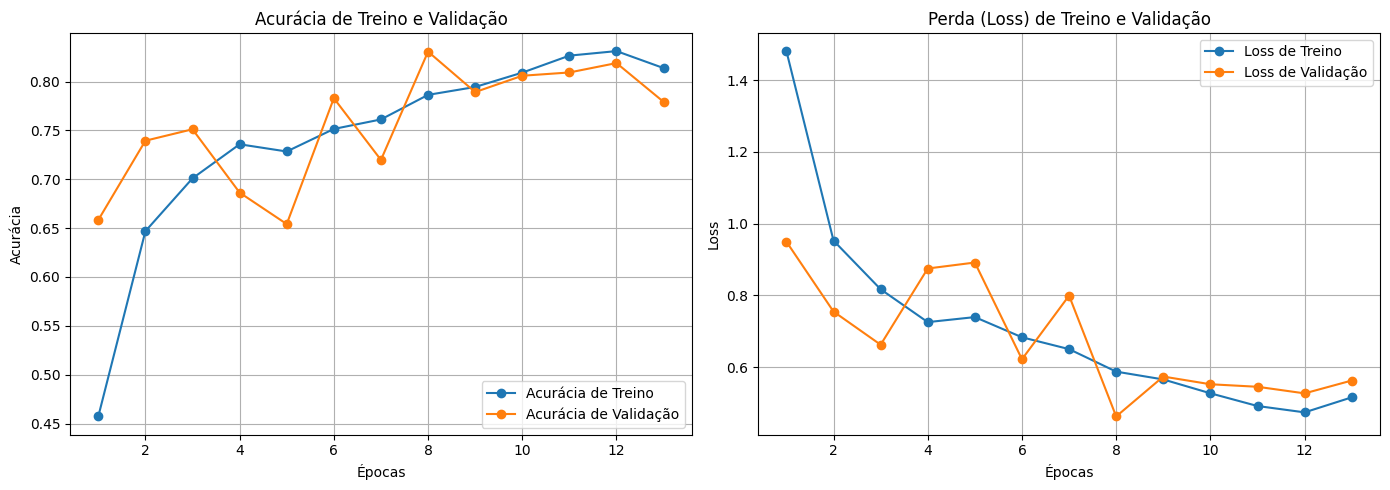

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [18]:
y_pred_probs = model_mel_espectograma.predict(test_ds)

y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Extract true labels from test_ds
y_true_indices = []
for _, labels in test_ds:
	y_true_indices.extend(labels.numpy())
y_true_indices = np.array(y_true_indices)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


2025-09-25 01:44:11.960075: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)

print(report)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

   _silence_       0.99      0.99      0.99       408
   _unknown_       0.77      0.68      0.72       466
          go       0.75      0.77      0.76       402
          no       0.75      0.82      0.79       405
         off       0.85      0.86      0.86       402
          on       0.93      0.84      0.88       396
        stop       0.84      0.93      0.89       411

    accuracy                           0.84      2890
   macro avg       0.84      0.84      0.84      2890
weighted avg       0.84      0.84      0.84      2890



--- Matriz de Confusão ---


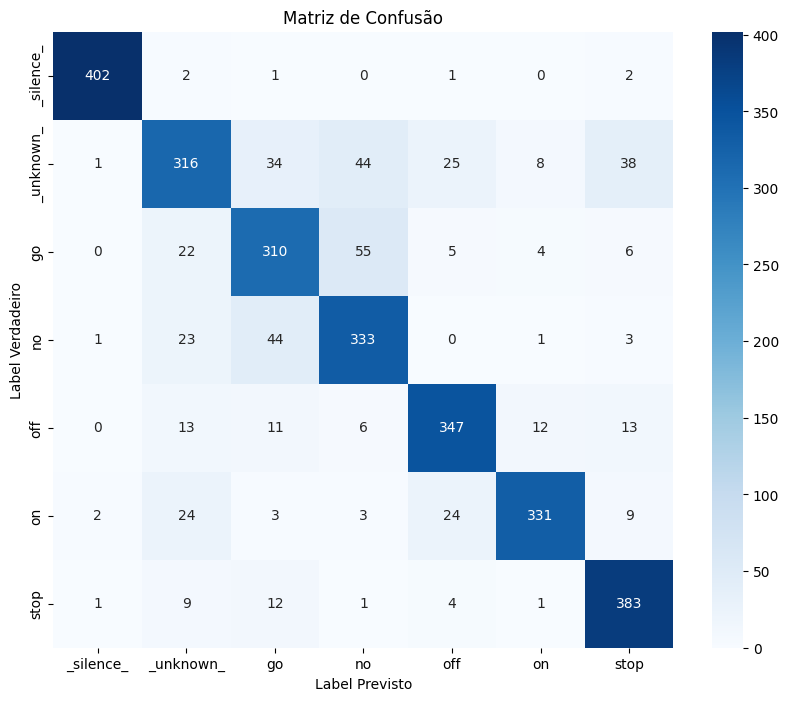

In [20]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

## With Data Augmentation:

In [20]:
DATA_DIR = Path('../dataset_augmented')

TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'validation'
TEST_DIR = DATA_DIR / 'test'

In [23]:
CLASS_NAMES = np.array([item.name for item in Path(TRAIN_DIR).glob('*') if item.is_dir()])
    
print(f"Classes encontradas: {CLASS_NAMES}")
NUM_CLASSES = len(CLASS_NAMES)

Classes encontradas: ['on' 'off' 'go' '_unknown_' 'no' 'stop' '_silence_']


In [22]:
print("\nCriando o dataset de treinamento...")
train_ds = create_dataset(TRAIN_DIR, shuffle=True)

print("Criando o dataset de validação...")
val_ds = create_dataset(VALID_DIR, shuffle=False)

print("Criando o dataset de teste...")
test_ds = create_dataset(TEST_DIR, shuffle=False)


Criando o dataset de treinamento...


I0000 00:00:1758775706.200045    5133 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9858 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


Criando o dataset de validação...
Criando o dataset de teste...



Formato (shape) do lote de mel-espectrogramas: (32, 61, 128, 1)
Formato (shape) do lote de rótulos: (32,)


2025-09-25 01:48:44.306101: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


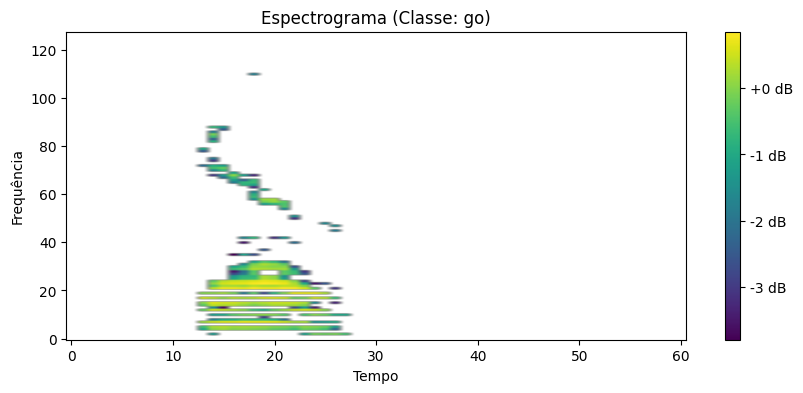

In [24]:
for mels, labels in train_ds.take(1):
    input_shape = mels.shape[1:]
    print(f"\nFormato (shape) do lote de mel-espectrogramas: {mels.shape}")
    print(f"Formato (shape) do lote de rótulos: {labels.shape}")
    
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.math.log(mels[0, :, :, 0] + 1e-6).numpy().T, aspect='auto', origin='lower')
    plt.title(f"Espectrograma (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Frequência")
    plt.xlabel("Tempo")
    plt.colorbar(format='%+2.0f dB')
    plt.show()
    break

### Training:

In [25]:
model_mel_espectograma_aug = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(7, activation='softmax')
])

model_mel_espectograma_aug.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 61, 128, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 61, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14336)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,670,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,818,055 (14.56 MB)

 Trainable params: 3,816,775 (14.56 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [26]:
model_mel_espectograma_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [27]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [28]:
history = model_mel_espectograma_aug.fit(train_ds, validation_data=val_ds, callbacks = callbacks, epochs=100, batch_size=BATCH_SIZE, verbose=1)

Epoch 1/100


I0000 00:00:1758775746.306632    6487 service.cc:152] XLA service 0x7004d8006ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758775746.306647    6487 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-09-25 01:49:06.349233: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758775746.559137    6487 cuda_dnn.cc:529] Loaded cuDNN version 91002


  25/3168 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.2868 - loss: 2.2925 

I0000 00:00:1758775748.902873    6487 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3168/3168 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - accuracy: 0.6778 - loss: 0.8669 - val_accuracy: 0.8177 - val_loss: 0.5166
Epoch 2/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.7987 - loss: 0.5467 - val_accuracy: 0.8511 - val_loss: 0.4318
Epoch 3/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8369 - loss: 0.4550 - val_accuracy: 0.8704 - val_loss: 0.3948
Epoch 4/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8474 - loss: 0.4236 - val_accuracy: 0.8900 - val_loss: 0.3051
Epoch 5/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8780 - loss: 0.3415 - val_accuracy: 0.8975 - val_loss: 0.2851
Epoch 6/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8920 - loss: 0.3011 - val_accuracy: 0.9088 - val_loss: 0.2597
Epoch 7/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9106 - loss: 0.2525 - val_accuracy: 0.8964 - val_loss: 0.2962
Epoch 8/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9193 - loss: 0.226

### Testing:

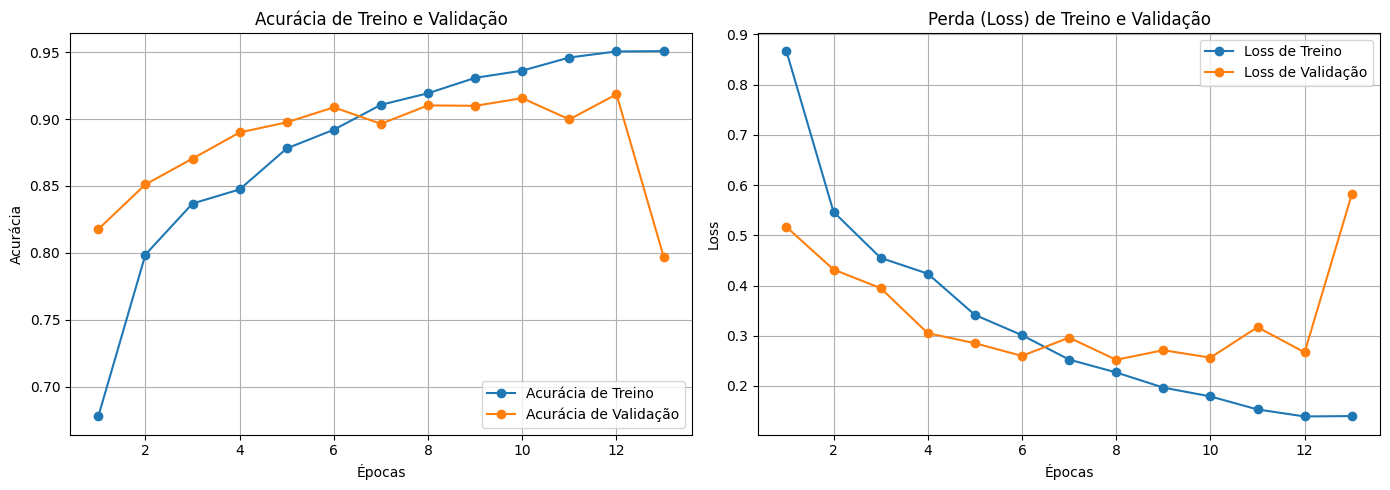

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [30]:
y_pred_probs = model_mel_espectograma_aug.predict(test_ds)

y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Extract true labels from test_ds
y_true_indices = []
for _, labels in test_ds:
	y_true_indices.extend(labels.numpy())
y_true_indices = np.array(y_true_indices)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


2025-09-25 01:54:20.287568: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [31]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)

print(report)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

          on       0.88      0.86      0.87       396
         off       0.89      0.88      0.88       402
          go       0.91      0.80      0.85       402
   _unknown_       0.66      0.81      0.73       466
          no       0.87      0.85      0.86       405
        stop       0.89      0.92      0.90       411
   _silence_       1.00      0.89      0.94       408

    accuracy                           0.86      2890
   macro avg       0.87      0.86      0.86      2890
weighted avg       0.87      0.86      0.86      2890



--- Matriz de Confusão ---


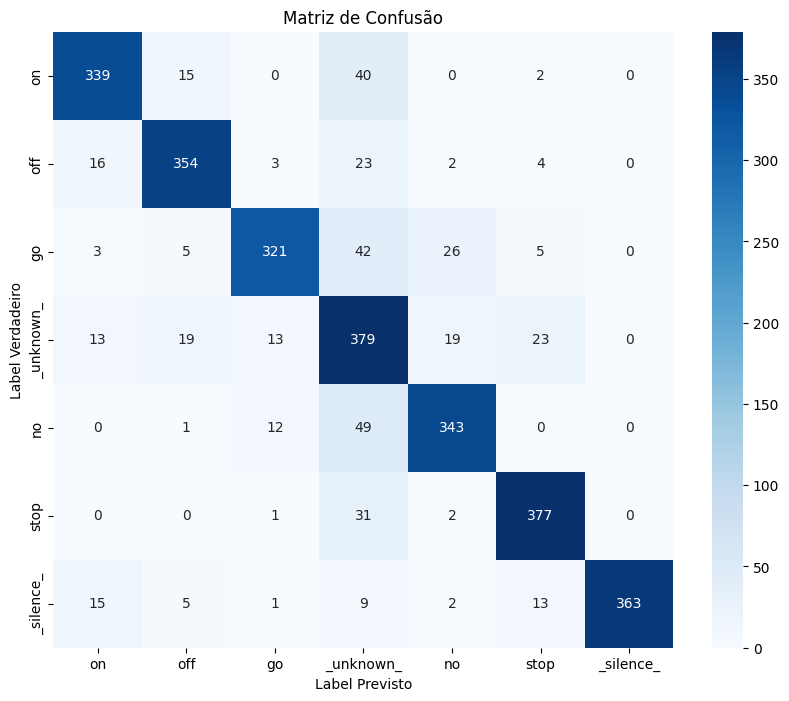

In [32]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

In [34]:
model_mel_espectograma_aug.save('../models/mel_spectrogram_model_augmented.keras')

## Gerando modelo .tflite (float16):

In [44]:
keras_model = tf.keras.models.load_model("../models/mel_spectrogram_model_augmented.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

In [46]:
print("\nIniciando conversão com quantização Float16...")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model_fp16 = converter.convert()

with open("../models/mel_spectrogram_fp16.tflite", 'wb') as f:
    f.write(tflite_model_fp16)
print(f"Modelo com Float16 Quantization salvo em ../models/mel_spectrogram_fp16.tflite")


Iniciando conversão com quantização Float16...
INFO:tensorflow:Assets written to: /tmp/tmpd0q8_l_g/assets


INFO:tensorflow:Assets written to: /tmp/tmpd0q8_l_g/assets


Saved artifact at '/tmp/tmpd0q8_l_g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 61, 128, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  123168726288336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168726293264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168726303664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168726305776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168726298896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168726301184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168726317744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168726315280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168724389904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168724386736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123168724386912:

W0000 00:00:1758776471.933394    5133 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1758776471.933404    5133 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-09-25 02:01:11.933487: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpd0q8_l_g
2025-09-25 02:01:11.934115: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-25 02:01:11.934119: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpd0q8_l_g
2025-09-25 02:01:11.940286: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-25 02:01:11.988286: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpd0q8_l_g
2025-09-25 02:01:11.999048: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 65562 microseconds.


## Testing .tflite model (float16):

In [ ]:
TFLITE_MODEL_PATH = Path('../models/mel_spectrogram_fp16.tflite')

In [48]:
print(f"Carregando modelo TFLite de: {TFLITE_MODEL_PATH}")
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))
interpreter.allocate_tensors()

Carregando modelo TFLite de: ../models/model_espectograma_fp16.tflite


/home/rolds/Documents/Projects/KeyWord Spotting Wonder/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/dev-env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [49]:
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("\n--- Detalhes do Modelo TFLite ---")
print(f"Entrada (Shape): {input_details['shape']}")
print(f"Entrada (Tipo): {input_details['dtype']}") # Deve ser float32
print(f"Saída (Shape): {output_details['shape']}")
print(f"Saída (Tipo): {output_details['dtype']}") # Deve ser float32


--- Detalhes do Modelo TFLite ---
Entrada (Shape): [  1  61 128   1]
Entrada (Tipo): <class 'numpy.float32'>
Saída (Shape): [1 7]
Saída (Tipo): <class 'numpy.float32'>


In [50]:
y_true = []
y_pred = []
total_samples = 0

print("Iniciando avaliação no dataset de teste...")
for data_batch, labels_batch in test_ds:
    # Iterar sobre cada amostra no lote
    for i in range(data_batch.shape[0]):
        # Pegar uma única amostra de dado
        sample_data = data_batch[i]
        
        # Adicionar a dimensão do lote (batch dimension) para corresponder ao shape da entrada do modelo
        input_tensor = np.expand_dims(sample_data, axis=0).astype(np.float32)

        # Definir o tensor de entrada, executar inferência e obter a saída
        # Não precisamos de nenhuma conversão manual, o interpretador cuida de tudo.
        interpreter.set_tensor(input_details['index'], input_tensor)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])
        
        # Armazenar o rótulo previsto e o rótulo verdadeiro
        predicted_label_index = np.argmax(output_data)
        y_pred.append(predicted_label_index)
        y_true.append(labels_batch[i].numpy())
        
    total_samples += data_batch.shape[0]
    print(f"Avaliadas {total_samples} amostras...")

print("\nAvaliação concluída.")

Iniciando avaliação no dataset de teste...
Avaliadas 32 amostras...
Avaliadas 64 amostras...
Avaliadas 96 amostras...
Avaliadas 128 amostras...
Avaliadas 160 amostras...
Avaliadas 192 amostras...
Avaliadas 224 amostras...
Avaliadas 256 amostras...
Avaliadas 288 amostras...
Avaliadas 320 amostras...
Avaliadas 352 amostras...
Avaliadas 384 amostras...
Avaliadas 416 amostras...
Avaliadas 448 amostras...
Avaliadas 480 amostras...
Avaliadas 512 amostras...
Avaliadas 544 amostras...
Avaliadas 576 amostras...
Avaliadas 608 amostras...
Avaliadas 640 amostras...
Avaliadas 672 amostras...
Avaliadas 704 amostras...
Avaliadas 736 amostras...
Avaliadas 768 amostras...
Avaliadas 800 amostras...
Avaliadas 832 amostras...
Avaliadas 864 amostras...
Avaliadas 896 amostras...
Avaliadas 928 amostras...
Avaliadas 960 amostras...
Avaliadas 992 amostras...
Avaliadas 1024 amostras...
Avaliadas 1056 amostras...
Avaliadas 1088 amostras...
Avaliadas 1120 amostras...
Avaliadas 1152 amostras...
Avaliadas 1184 amos

2025-09-25 02:02:00.194258: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [51]:
print("\n--- Relatório de Classificação ---")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)


--- Relatório de Classificação ---
              precision    recall  f1-score   support

          on       0.88      0.86      0.87       396
         off       0.89      0.88      0.89       402
          go       0.91      0.80      0.85       402
   _unknown_       0.66      0.81      0.73       466
          no       0.87      0.85      0.86       405
        stop       0.89      0.92      0.90       411
   _silence_       1.00      0.89      0.94       408

    accuracy                           0.86      2890
   macro avg       0.87      0.86      0.86      2890
weighted avg       0.87      0.86      0.86      2890




--- Matriz de Confusão ---


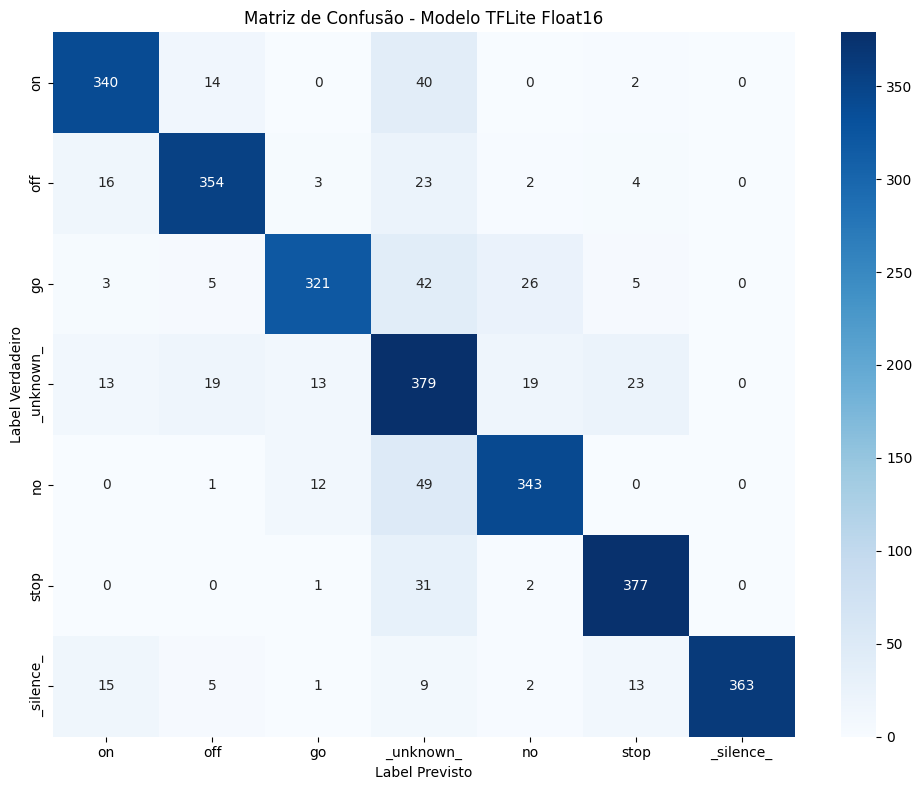

In [52]:
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão - Modelo TFLite Float16')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.tight_layout()
plt.show()